In [1]:
library(Seurat)
library(tidyverse)
library(SeuratWrappers)
library(future)
library(ggplot2)
library(SeuratObject)
library(viridis)
library(purrr)
library(scales)
library(presto)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(purrr)
library(tidyr)
library(pheatmap)

Warning message:
“package ‘Seurat’ was built under R version 4.4.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.4.3”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_confl

# Load Data

In [ ]:
obj <- readRDS("/mnt/18T/chibao/gliomas/data_official/01_integrated_obj/01_integrated_annotated_official.rds")
obj 
obj@meta.data |> head()
obj$general_cell_type |> unique()

An object of class Seurat 
74637 features across 346898 samples within 2 assays 
Active assay: SCT (36031 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 4 dimensional reductions calculated: pca, umap, harmony, umap.harmony

,orig.ident,nCount_RNA,nFeature_RNA,project_id,orig_sample_id,sample_uid,genome,chemistry,percent.mt,doublet_class,⋯,SCT_snn_res.0.2,SCT_snn_res.0.4,SCT_snn_res.0.5,SCT_snn_res.0.6,SCT_snn_res.0.7,SCT_snn_res.0.8,SCT_snn_res.1,SCT_snn_res.1.2,seurat_clusters,general_cell_type
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCAAGTCAAGCG-1,PRJNA1125010,6520,1839,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,6.1196319,singlet,⋯,5,33,36,31,31,31,51,49,49,NPC_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCACATTGCCGG-1,PRJNA1125010,4533,1962,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,14.7804986,singlet,⋯,10,6,20,18,21,19,18,32,32,Mesenchymal_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGAAAGCTCTGTA-1,PRJNA1125010,50471,7374,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,7.7450417,singlet,⋯,4,3,2,1,3,0,25,18,18,OPC_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGAATCCCATAAG-1,PRJNA1125010,41082,7762,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,5.9661165,singlet,⋯,5,37,19,21,20,32,35,58,58,NPC_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGCTAGTCACTAC-1,PRJNA1125010,11161,3306,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,0.5286265,singlet,⋯,4,3,2,1,3,0,25,18,18,OPC_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAAGAACAGTGTCATC-1,PRJNA1125010,2965,1417,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,8.5666105,singlet,⋯,23,34,35,37,39,39,41,42,42,Endothelial


In [3]:
target_types <- c("Astrocyte_like", "OPC_like", "Mesenchymal_like", "NPC_like")

obj_tumor <- subset(obj, subset = general_cell_type %in% target_types)

DefaultAssay(obj_tumor) <- "RNA"  # as before
all_genes <- rownames(obj_tumor)

In [4]:
obj_tumor@meta.data |> head()

,orig.ident,nCount_RNA,nFeature_RNA,project_id,orig_sample_id,sample_uid,genome,chemistry,percent.mt,doublet_class,⋯,SCT_snn_res.0.2,SCT_snn_res.0.4,SCT_snn_res.0.5,SCT_snn_res.0.6,SCT_snn_res.0.7,SCT_snn_res.0.8,SCT_snn_res.1,SCT_snn_res.1.2,seurat_clusters,general_cell_type
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCAAGTCAAGCG-1,PRJNA1125010,6520,1839,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,6.1196319,singlet,⋯,5,33,36,31,31,31,51,49,49,NPC_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCACATTGCCGG-1,PRJNA1125010,4533,1962,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,14.7804986,singlet,⋯,10,6,20,18,21,19,18,32,32,Mesenchymal_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGAAAGCTCTGTA-1,PRJNA1125010,50471,7374,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,7.7450417,singlet,⋯,4,3,2,1,3,0,25,18,18,OPC_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGAATCCCATAAG-1,PRJNA1125010,41082,7762,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,5.9661165,singlet,⋯,5,37,19,21,20,32,35,58,58,NPC_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGCTAGTCACTAC-1,PRJNA1125010,11161,3306,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,0.5286265,singlet,⋯,4,3,2,1,3,0,25,18,18,OPC_like
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAAGGATAGTACTGGG-1,PRJNA1125010,7268,2835,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,1.0044029,singlet,⋯,1,9,37,7,38,1,40,20,20,Astrocyte_like


# Module Score

In [5]:
# ========= NPC-like =========
npc_genes_raw <- c("DLL3", "DLL1", "SOX4", "TUBB3", "HES6", "TAGLN3", "NEU4", "MARCKSL1", "CD24", "STMN1", "TCF12", 
"BEX1", "MAP2", "PTPRS", "MLLT11", "NPPA", "MEST", "ASCL1", "BTG2", "NXPH1", "HN1", "PFN2", 
"SCG3", "MYT1", "CHD7", "GPR56", "TUBA1A", "PCBP4", "BTV1", "SHD", "AMOTL2", "DBN1", "HIP1", "ABAT", "ELAVL4", 
"GRIK2", "TSPAN13", "ELMO1", "GLCCI1", "SEZ6L", "LRRN1", "SEZ6", "SOX11", "STMN2", "RND3", "HMP19", 
"MIAT", "DCX", "NSG1", "DLX6-AS1", "NREP", "FNBp1L", "STMN4", "DLX5", "MAP1B", "RBFOX2", "IGFBPL1", "TMEM161B-AS1", "DPYSL3", 
"SEPT3", "PKIA", "ATP1B1", "DYNC1I1", "CD200", "SNAP25", "PAK3", "NDRG4", "KIF5A", "UCHL1", "KIF5C", "DDAH2", "TUBB2A", 
"LBH", "LOC150568", "TCF4", "GNG3", "NFIB", "DPYSL5", "CRABP1", "NFIX", "CEF170", "BLCAP")

# ========= OPC-like =========
opc_genes_raw <- c("BCAN", "PLP1", "GPR17", "FIBIN", "LHFPL3", "OLIG1", "PSAT1", "SCRG1", "OMG", "APOD", "SIRT2", 
"TNR", "THY1", "PHYHIPL", "SOX2-OT", "NKAIN4", "LPPR1", "PTPRZ1", "VCAN", "CNP", "TNS3", "LIMA1", "CA10", 
"PCDHGC3", "CNTN1", "SCD5", "P2RX7", "CADM2", "FGF12", "TMEM206", "TNEU4", "FXYD6", "RNF13", "RTKN", "GPM6B", "LMF1", 
"ALCAM", "PGRMC1", "HRASLS", "BCAS1", "RAB31", "PLLP", "FABP5", "NLGN3", "SERINC5", "EFNB4L2", "GPR37L1")

# ========= AC-like (astrocyte-like) =========
ac_genes_raw <- c("CST3", "S100B", "SLC1A3", "HEPN1", "HOPX", "MT3", "SPARCL1", "MLC1", "GFAP", "FABP7", 
"PON2", "METTL7B", "SPARC", "GATM", "RAMP1", "PMP2", "AQP4", "DBI", "EDNRB", "CLU", 
"PMP22", "ATP1A2", "HEY1", "TTYH1", "NDRG2", "PRCP", "ATP1B2", "AGT", "PLTP", "F3", 
"PPAP2B", "ANXA5", "TSPAN7", "PEG10", "RFX4", "SLC4A4", "TENM1")

# ========= MES-like =========
mes_genes_raw <- c("CHI3L1", "VEGFA", "ANXA2", "ANXA1", "CD44", "MT2A", "C1S", "EFEMP1", 
"C1R", "SOD2", "IFITM3", "TIMP1", "SPP1", "A2M", "S100A11", "MT1X", "S100A10", "FN1", 
"LGALS1", "S100A16", "CLIC1", "MGST1", "RCAN1", "TAGLN2", "NPC2", "SERPING1", "C8orf4", 
"EMP1", "APOE", "CTSB", "C3", "LGALS3", "MT1E", "EMP3", "SERPINA3", "ACTN1", "PRDX6", 
"IGFBP7", "SERPINE1", "PLP2", "MGP", "CLIC4", "GFPT2", "GSN", "NNMT", "TUBA1C", "GJA1", 
"TNFRSF1A", "WWTR1", "HILPDA", "ADM", "DDIT3", "NDRG1", "HERPUD1", "DNAJB9", "TRIB3", 
"ENO2", "AKAP12", "SQSTM1", "ATF3", "NAMPT", "NRN1", "SLC2A1", "BNIP3", "INSIG2", "IGFBP3", 
"PPP1R15A", "VIM", "PLOD2", "GBE1", "SLC2A3", "FTL", "WARS", "ERO1L", "XPO1", "HSPA5", "GDF15", 
"EPAS1", "LDHA", "P4HA1", "SERTAD1", "PFKP", "PGK1", "EGLN3", "SLC6A6", "CA9", "BNIP3L", "RPL21", 
"TRAM1", "UFM1", "ASNS", "GOLT1B", "ANGPTL4", "SLC39A14", "CDKN1A", "HSPA9")

In [6]:
all_genes <- rownames(obj_tumor)
all_genes |> head()

[1] "DDX11L2"         "MIR1302-2HG"     "FAM138A"         "ENSG00000290826"
[5] "OR4F5"           "ENSG00000238009"

In [7]:
filter_genes <- function(g) {
  present <- intersect(g, all_genes)
  missing <- setdiff(g, all_genes)
  list(present = present, missing = missing)
}

In [8]:
# rebuild npc/opc/ac/mes lists on obj_tumor
npc_genes <- filter_genes(npc_genes_raw)
opc_genes   <- filter_genes(opc_genes_raw)
ac_genes    <- filter_genes(ac_genes_raw)
mes_genes <- filter_genes(mes_genes_raw)

In [10]:
# Run AddModuleScore for each module
obj_tumor <- AddModuleScore(obj_tumor, features = list(npc_genes$present), name = "NPC_like")
obj_tumor <- AddModuleScore(obj_tumor, features = list(opc_genes$present), name = "OPC_like")
obj_tumor <- AddModuleScore(obj_tumor, features = list(ac_genes$present), name = "AC_like")
obj_tumor <- AddModuleScore(obj_tumor, features = list(mes_genes$present), name = "MES_like")

In [11]:
obj_tumor
obj_tumor@meta.data |> head()

An object of class Seurat 
74637 features across 121339 samples within 2 assays 
Active assay: RNA (38606 features, 0 variable features)
 11 layers present: counts, data.PRJNA1125010, data.PRJNA1131103, data.PRJNA1134206, data.PRJNA1141154, data.PRJNA1212512, data.PRJNA683876, data.PRJNA797449, data.PRJNA887804, data.PRJNA887805, data.PRJNA995768
 1 other assay present: SCT
 4 dimensional reductions calculated: pca, umap, harmony, umap.harmony

,orig.ident,nCount_RNA,nFeature_RNA,project_id,orig_sample_id,sample_uid,genome,chemistry,percent.mt,doublet_class,⋯,SCT_snn_res.0.7,SCT_snn_res.0.8,SCT_snn_res.1,SCT_snn_res.1.2,seurat_clusters,general_cell_type,NPC_like1,OPC_like1,AC_like1,MES_like1
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCAAGTCAAGCG-1,PRJNA1125010,6520,1839,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,6.1196319,singlet,⋯,31,31,51,49,49,NPC_like,-6.090432e-05,-0.03659566,0.04437696,0.18295376
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCACATTGCCGG-1,PRJNA1125010,4533,1962,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,14.7804986,singlet,⋯,21,19,18,32,32,Mesenchymal_like,1.013108e-01,0.12074388,0.41127486,0.26404542
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGAAAGCTCTGTA-1,PRJNA1125010,50471,7374,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,7.7450417,singlet,⋯,3,0,25,18,18,OPC_like,3.438822e-01,0.55454222,-0.27537960,-0.02986853
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGAATCCCATAAG-1,PRJNA1125010,41082,7762,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,5.9661165,singlet,⋯,20,32,35,58,58,NPC_like,-1.191669e-02,0.09647191,-0.06068470,0.05297557
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACGCTAGTCACTAC-1,PRJNA1125010,11161,3306,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,0.5286265,singlet,⋯,3,0,25,18,18,OPC_like,1.741581e-01,0.43215652,-0.31938051,-0.11201371
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAAGGATAGTACTGGG-1,PRJNA1125010,7268,2835,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,1.0044029,singlet,⋯,38,1,40,20,20,Astrocyte_like,-3.200062e-03,0.06369065,-0.13391372,0.06704343


In [12]:
# Find the score columns ending in '1'
score_cols <- grep("_like1$", colnames(obj_tumor@meta.data), value = TRUE)
score_cols

[1] "NPC_like1" "OPC_like1" "AC_like1"  "MES_like1"

In [13]:
# Create new names by removing the final '1'
new_names  <- sub("1$", "", score_cols)
new_names

[1] "NPC_like" "OPC_like" "AC_like"  "MES_like"

In [14]:
# Assign them back
idx <- match(score_cols, colnames(obj_tumor@meta.data))
colnames(obj_tumor@meta.data)[idx] <- new_names

In [15]:
obj_tumor@meta.data |> head(2)

,orig.ident,nCount_RNA,nFeature_RNA,project_id,orig_sample_id,sample_uid,genome,chemistry,percent.mt,doublet_class,⋯,SCT_snn_res.0.7,SCT_snn_res.0.8,SCT_snn_res.1,SCT_snn_res.1.2,seurat_clusters,general_cell_type,NPC_like,OPC_like,AC_like,MES_like
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCAAGTCAAGCG-1,PRJNA1125010,6520,1839,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,6.119632,singlet,⋯,31,31,51,49,49,NPC_like,-6.090432e-05,-0.03659566,0.04437696,0.1829538
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AAACCCACATTGCCGG-1,PRJNA1125010,4533,1962,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,14.780499,singlet,⋯,21,19,18,32,32,Mesenchymal_like,1.013108e-01,0.12074388,0.41127486,0.2640454


In [16]:
cluster_col <- "general_cell_type"

cluster_scores <- obj_tumor@meta.data %>%
  dplyr::select(all_of(cluster_col), NPC_like, OPC_like, AC_like, MES_like) %>%
  group_by(.data[[cluster_col]]) %>%
  summarise(
    NPC_mean = mean(NPC_like, na.rm = TRUE),
    OPC_mean  = mean(OPC_like,  na.rm = TRUE),
    AC_mean   = mean(AC_like,   na.rm = TRUE),
    MES_mean = mean(MES_like, na.rm = TRUE)
  ) %>%
  ungroup()

cluster_scores

general_cell_type,NPC_mean,OPC_mean,AC_mean,MES_mean
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Astrocyte_like,0.04371805,0.13220823,0.18138248,0.168949595
Mesenchymal_like,-0.01526624,-0.00167345,0.29155465,0.389660320
NPC_like,0.11984352,0.03460836,0.03002729,0.068847284
OPC_like,0.18093983,0.31107657,-0.04090973,0.001564285


In [17]:
gene_map <- list(
  "NPC_like"         = npc_genes$present,
  "OPC_like"         = opc_genes$present,
  "Astrocyte_like"   = ac_genes$present,
  "Mesenchymal_like" = mes_genes$present
)

gene_map |> head()

$NPC_like
 [1] "DLL3"     "DLL1"     "SOX4"     "TUBB3"    "HES6"     "TAGLN3"  
 [7] "NEU4"     "MARCKSL1" "CD24"     "STMN1"    "TCF12"    "BEX1"    
[13] "MAP2"     "PTPRS"    "MLLT11"   "NPPA"     "MEST"     "ASCL1"   
[19] "BTG2"     "NXPH1"    "PFN2"     "SCG3"     "MYT1"     "CHD7"    
[25] "TUBA1A"   "PCBP4"    "SHD"      "AMOTL2"   "DBN1"     "HIP1"    
[31] "ABAT"     "ELAVL4"   "GRIK2"    "TSPAN13"  "ELMO1"    "GLCCI1"  
[37] "SEZ6L"    "LRRN1"    "SEZ6"     "SOX11"    "STMN2"    "RND3"    
[43] "MIAT"     "DCX"      "NSG1"     "DLX6-AS1" "NREP"     "STMN4"   
[49] "DLX5"     "MAP1B"    "RBFOX2"   "IGFBPL1"  "DPYSL3"   "PKIA"    
[55] "ATP1B1"   "DYNC1I1"  "CD200"    "SNAP25"   "PAK3"     "NDRG4"   
[61] "KIF5A"    "UCHL1"    "KIF5C"    "DDAH2"    "TUBB2A"   "LBH"     
[67] "TCF4"     "GNG3"     "NFIB"     "DPYSL5"   "CRABP1"   "NFIX"    
[73] "BLCAP"   

$OPC_like
 [1] "BCAN"    "PLP1"    "GPR17"   "FIBIN"   "LHFPL3"  "OLIG1"   "PSAT1"  
 [8] "SCRG1"   "OMG"     "APOD"    "SIRT2"   "TNR"     "THY1"    "PHYHIPL"
[15] "SOX2-OT" "NKAIN4"  "PTPRZ1"  "VCAN"    "CNP"     "TNS3"    "LIMA1"  
[22] "CA10"    "PCDHGC3" "CNTN1"   "SCD5"    "P2RX7"   "CADM2"   "FGF12"  
[29] "FXYD6"   "RNF13"   "RTKN"    "GPM6B"   "LMF1"    "ALCAM"   "PGRMC1" 
[36] "BCAS1"   "RAB31"   "PLLP"    "FABP5"   "NLGN3"   "SERINC5" "GPR37L1"

$Astrocyte_like
 [1] "CST3"    "S100B"   "SLC1A3"  "HEPN1"   "HOPX"    "MT3"     "SPARCL1"
 [8] "MLC1"    "GFAP"    "FABP7"   "PON2"    "METTL7B" "SPARC"   "GATM"   
[15] "RAMP1"   "PMP2"    "AQP4"    "DBI"     "EDNRB"   "CLU"     "PMP22"  
[22] "ATP1A2"  "HEY1"    "TTYH1"   "NDRG2"   "PRCP"    "ATP1B2"  "AGT"    
[29] "PLTP"    "F3"      "ANXA5"   "TSPAN7"  "PEG10"   "RFX4"    "SLC4A4" 
[36] "TENM1"  

$Mesenchymal_like
 [1] "CHI3L1"   "VEGFA"    "ANXA2"    "ANXA1"    "CD44"     "MT2A"    
 [7] "C1S"      "EFEMP1"   "C1R"      "SOD2"     "IFITM3"   "TIMP1"   
[13] "SPP1"     "A2M"      "S100A11"  "MT1X"     "S100A10"  "FN1"     
[19] "LGALS1"   "S100A16"  "CLIC1"    "MGST1"    "RCAN1"    "TAGLN2"  
[25] "NPC2"     "SERPING1" "EMP1"     "APOE"     "CTSB"     "C3"      
[31] "LGALS3"   "MT1E"     "EMP3"     "SERPINA3" "ACTN1"    "PRDX6"   
[37] "IGFBP7"   "SERPINE1" "PLP2"     "MGP"      "CLIC4"    "GFPT2"   
[43] "GSN"      "NNMT"     "TUBA1C"   "GJA1"     "TNFRSF1A" "WWTR1"   
[49] "HILPDA"   "ADM"      "DDIT3"    "NDRG1"    "HERPUD1"  "DNAJB9"  
[55] "TRIB3"    "ENO2"     "AKAP12"   "SQSTM1"   "ATF3"     "NAMPT"   
[61] "NRN1"     "SLC2A1"   "BNIP3"    "INSIG2"   "IGFBP3"   "PPP1R15A"
[67] "VIM"      "PLOD2"    "GBE1"     "SLC2A3"   "FTL"      "XPO1"    
[73] "HSPA5"    "GDF15"    "EPAS1"    "LDHA"     "P4HA1"    "SERTAD1" 
[79] "PFKP"     "PGK1"     "EGLN3"    "SLC6A6"   "CA9"      "BNIP3L"  
[85] "RPL21"    "TRAM1"    "UFM1"     "ASNS"     "GOLT1B"   "ANGPTL4" 
[91] "SLC39A14" "CDKN1A"   "HSPA9"

In [18]:
get_top_contributors <- function(seurat_obj, cell_type, gene_list, top_n = 10) {
  
  # A. Subset to the specific cell type
  # We use the subsetted object to calculate means only for these cells
  subset_obj <- subset(seurat_obj, subset = general_cell_type == cell_type)
  
  # B. Fetch expression data (Slot 'data' = log-normalized counts, used by AddModuleScore)
  # We only fetch the genes in our specific module list
  expr_data <- GetAssayData(subset_obj, slot = "data", assay = "RNA")[gene_list, , drop = FALSE]
  
  # C. Calculate mean expression for each gene across these cells
  mean_expr <- rowMeans(expr_data)
  
  # D. Sort decreasingly to find highest expressors
  top_genes <- sort(mean_expr, decreasing = TRUE)[1:top_n]
  
  # E. Format as a clean data frame for viewing
  result <- data.frame(
    Gene = names(top_genes),
    Mean_Expression = as.numeric(top_genes),
    Cell_Type = cell_type
  )
  
  return(result)
}

In [19]:
backup <- obj_tumor
backup
obj_tumor <- JoinLayers(obj_tumor)
obj_tumor

An object of class Seurat 
74637 features across 121339 samples within 2 assays 
Active assay: RNA (38606 features, 0 variable features)
 11 layers present: counts, data.PRJNA1125010, data.PRJNA1131103, data.PRJNA1134206, data.PRJNA1141154, data.PRJNA1212512, data.PRJNA683876, data.PRJNA797449, data.PRJNA887804, data.PRJNA887805, data.PRJNA995768
 1 other assay present: SCT
 4 dimensional reductions calculated: pca, umap, harmony, umap.harmony

An object of class Seurat 
74637 features across 121339 samples within 2 assays 
Active assay: RNA (38606 features, 0 variable features)
 2 layers present: data, counts
 1 other assay present: SCT
 4 dimensional reductions calculated: pca, umap, harmony, umap.harmony

In [20]:
results_list <- list()

In [21]:
obj_tumor@meta.data$general_cell_type |> unique()

[1] "NPC_like"         "Mesenchymal_like" "OPC_like"         "Astrocyte_like"

In [22]:
# Loop through the map and calculate for each
for (ctype in names(gene_map)) {
  # Check if the cell type actually exists in the object to avoid errors
  if (ctype %in% unique(obj_tumor$general_cell_type)) {
    cat("Calculating top genes for:", ctype, "\n")
    res <- get_top_contributors(obj_tumor, ctype, gene_map[[ctype]])
    results_list[[ctype]] <- res
  } else {
    cat("Skipping", ctype, "- not found in object metadata.\n")
  }
}

Calculating top genes for: NPC_like 


Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


Calculating top genes for: OPC_like 
Calculating top genes for: Astrocyte_like 
Calculating top genes for: Mesenchymal_like 


In [23]:
# Combine all results into one table
final_contributors <- do.call(rbind, results_list)
rownames(final_contributors) <- NULL

In [24]:
# View the table
print(final_contributors)

       Gene Mean_Expression        Cell_Type
1    TUBA1A       2.0409088         NPC_like
2      SOX4       1.3143154         NPC_like
3  MARCKSL1       1.1670531         NPC_like
4      TCF4       1.1573557         NPC_like
5     TCF12       1.1117777         NPC_like
6     STMN1       1.0999493         NPC_like
7      MAP2       1.0514367         NPC_like
8     MAP1B       1.0280728         NPC_like
9    RBFOX2       0.9196928         NPC_like
10     NFIB       0.9058517         NPC_like
11    CADM2       2.2844923         OPC_like
12   PTPRZ1       2.1428484         OPC_like
13  SOX2-OT       2.0904658         OPC_like
14   LHFPL3       2.0568558         OPC_like
15    GPM6B       1.6731823         OPC_like
16     SCD5       1.3764326         OPC_like
17    ALCAM       1.3697555         OPC_like
18    FGF12       1.3697216         OPC_like
19      TNR       1.2656156         OPC_like
20     VCAN       1.2066256         OPC_like
21      CLU       1.4927232   Astrocyte_like
22   SLC1A

In [26]:
top_ac_gene <- results_list[["Astrocyte_like"]]$Gene[1:10]
top_mes_gene <- results_list[["Mesenchymal_like"]]$Gene[1:10]
top_op_gene <-  results_list[["OPC_like"]]$Gene[1:10]
top_np_gene <- results_list[["NPC_like"]]$Gene[1:10]

In [27]:
top_ac_gene |> head(2)
top_mes_gene |> head(2)
top_op_gene |> head(2)
top_np_gene |> head(2)

[1] "CLU"    "SLC1A3"

[1] "VIM" "FTL"

[1] "CADM2"  "PTPRZ1"

[1] "TUBA1A" "SOX4"

In [28]:
majorDot <- function(seu.obj = NULL, groupBy = "",
                     yAxis = NULL, scale = T,
                     features = "", split.by = NULL, cols = c("lightgrey", "blue"), cluster.idents = F
                    ){
    
    t <- try(head(seu.obj@assays$SCT$data),silent = T)

    # if("try-error" %in% class(t)){
    #     seu.obj <- ScaleData(seu.obj)
    # }
                       
    p <- DotPlot(seu.obj,
                 assay = "SCT",
                 features = features,
                 group.by = groupBy,
                 cols = cols,
                 scale = scale,
                 split.by = split.by#,
                 #idents = levels(seu.obj@meta.data[[groupBy]]),
                 #cluster.idents = cluster.idents
                ) +
      geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
      labs(size='Percent\nexpression')  +
      theme(axis.line = element_blank(),
            axis.text.x = element_text(angle = 45, vjust = 1, hjust=1),
            legend.position = "top",
            legend.direction = "horizontal",
            legend.justification='center',
            panel.background = element_rect(fill = "white",colour = NA),
            plot.background = element_rect(fill = "white",colour = NA),
            legend.key.size = unit(1, "line"),
            panel.border = element_rect(color = "black",
                                        fill = NA,
                                        size = 1),
            ) +
      scale_colour_viridis(option="magma", name='Average\nexpression') +
      guides(size=guide_legend(override.aes = list(shape=21, colour="black", fill="white"),
                               label.position = "bottom")) +
      scale_size(range = c(0.5, 8), limits = c(0, 100)) +
      #annotate("rect", xmin = features_cnt$startVal, xmax = features_cnt$endVal, ymin = features_cnt$cluster-0.5, ymax = features_cnt$cluster+0.5, fill = NA, colour = "mediumpurple1", size = 1) +
      {if(!is.null(yAxis)){scale_y_discrete(limits=rev(yAxis))}} +
      guides(color = guide_colorbar(title = 'Scaled\nExpression')) 
      
    
    return(p)
}

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


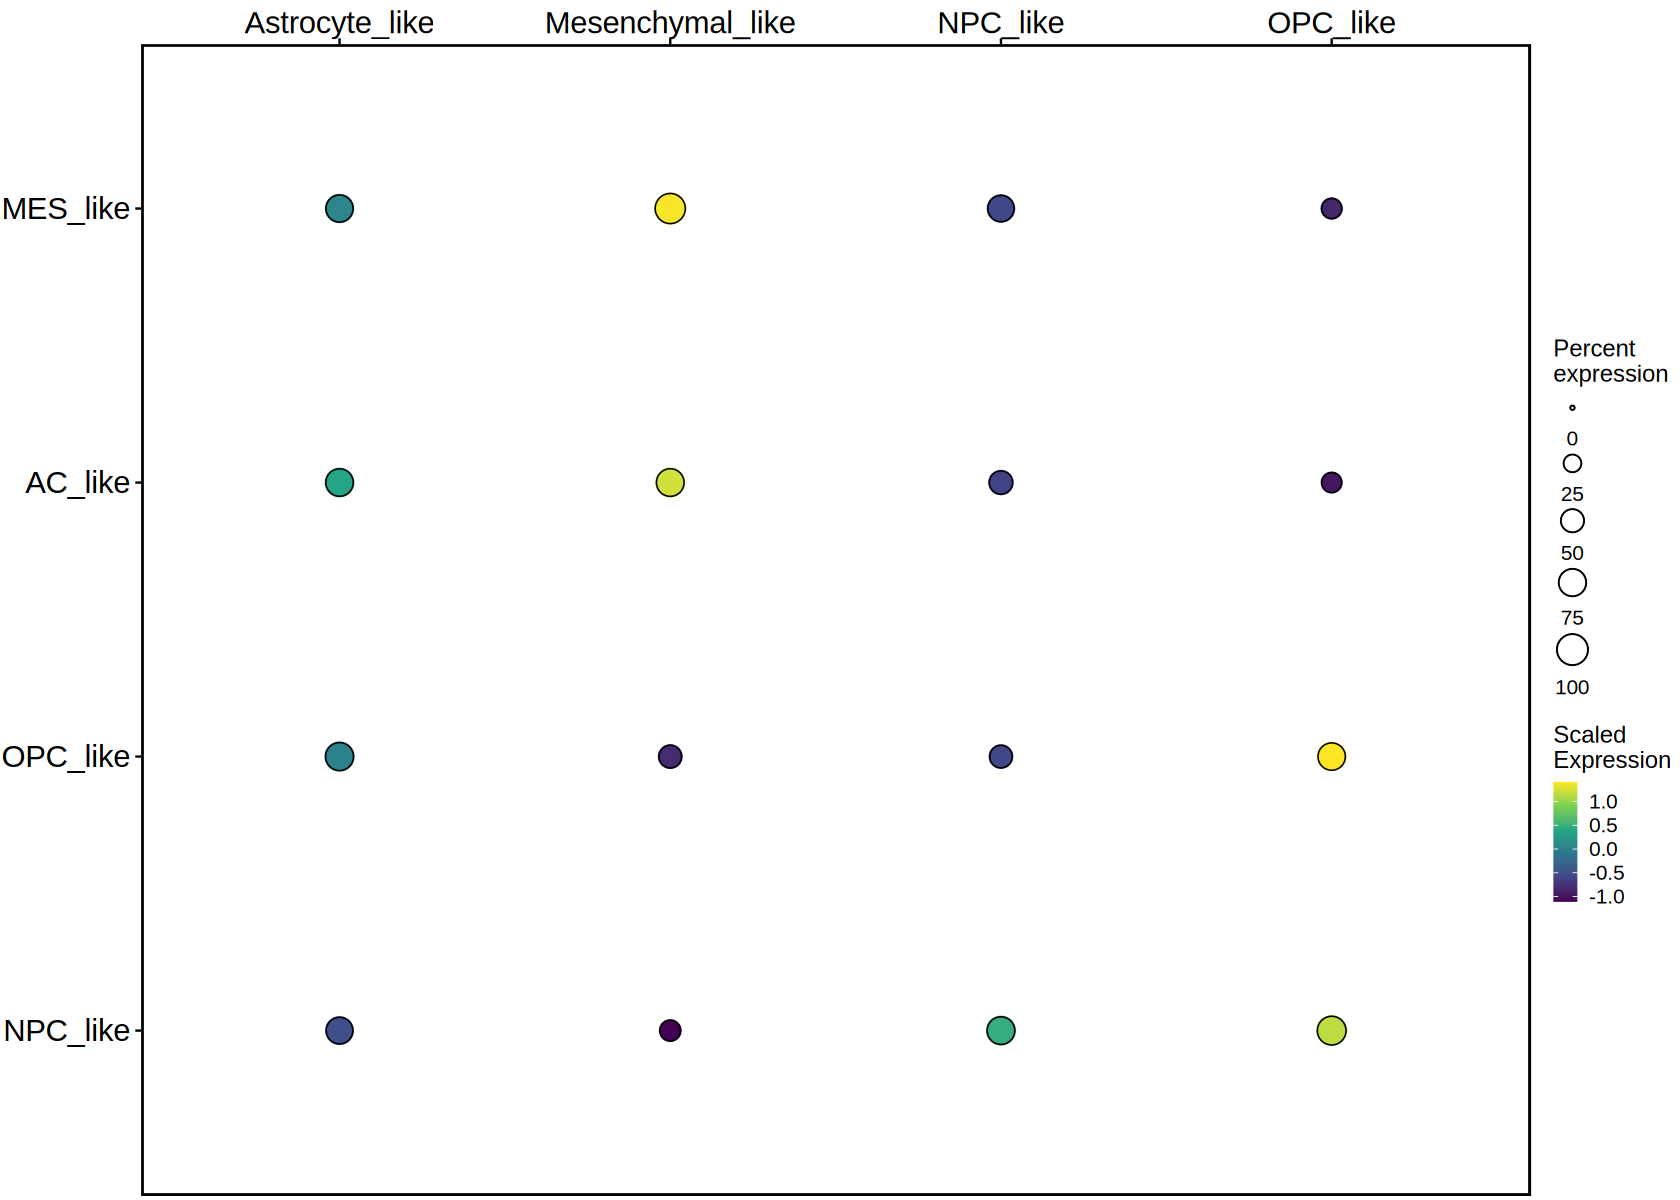

In [29]:
options(repr.plot.width = 14, repr.plot.height = 10)
ecScores <- majorDot(
  seu.obj   = obj_tumor,
  groupBy   = "general_cell_type",         # or any meta.data column
  features  = new_names,                 # your seven *_score columns
  scale     = TRUE,
  split.by  = NULL
) + coord_flip() + theme(plot.margin = margin(3, 0, 3, 0, "pt"),
                                             axis.text.y=element_text(size=18),
                                                                   axis.title = element_blank(),
                                                                   legend.position = "right",
                                                                   legend.direction = "vertical",
                                                                   axis.text.x = element_text(angle=0, hjust = 0.5, size = 18)
                                            ) + scale_y_discrete(position = "right") + scale_colour_continuous(name="Enrichment score", type = "viridis")
ecScores

In [30]:
# after you have computed and renamed your *_score1 → *_score columns…
modulez <- list(
  "Enrichment_score" = new_names,       # <- use the actual score column names
  Astrocyte        = ac_genes_raw,
  OPC            = opc_genes_raw,
  Mesenchymal        = mes_genes_raw,
  NPC                = npc_genes_raw
)

In [31]:
#plot indivdual members of each term
labelz <- as.data.frame(names(modulez))
colnames(labelz) <- "labz"
labelz$modLen <- unname(unlist(lapply(modulez, length)))
cntr <- 0
plots <- lapply(modulez, function(x){
    cntr <<- cntr+1
    labz.df <- labelz[cntr,]

    majorDot(seu.obj = obj_tumor, groupBy = "general_cell_type",
                     features = rev(unname(unlist(x)))
                    ) + theme(axis.text.x = element_blank(),
                              axis.text.y = element_text(size = 18),
                                                          axis.ticks = element_blank(),
                                                          legend.position = "right",
                                                                   legend.direction = "vertical",
                                                          axis.title = element_blank(),
                                                          plot.margin = margin(5, 0, 5, 0, "pt")
                                                         ) + scale_colour_distiller(palette = "RdYlBu", name='Average\nexpression', limits = c(-2.5,2.5)) + 
    geom_text(data = labz.df, aes(label = labz, y = 10.5, x = (modLen+1)/2, size = 10),
             angle = 270, vjust = 0.5, hjust=0.5, size = 8) + coord_flip(ylim = c(1,10.75), clip = "off") + annotate("segment", x = -Inf, y = 9.65, xend = Inf, yend = 9.65, lineend = "round", linejoin = "bevel", linetype ="solid", colour = "grey70", alpha = 0.7,size = 0.5)    
})

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The following requested variables were not found: PPAP2B”
Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will repla

In [32]:
# 2. DEFINE CUSTOM PLOTTING FUNCTION
# -----------------------------------------------------------------
create_publication_dotplot <- function(seu_obj, 
                                       features, 
                                       group_by, 
                                       scale_data = TRUE,
                                       dot_range = c(0.5, 8)) {
  
  # A. Data Extraction & Pre-calculation
  # We use the internal mechanics of Seurat's DotPlot to handle the 
  # complex calculation of "Percent Expressed" and "Average Scaled Expression".
  # This saves us from writing the math manually but allows us to hijack the data.
  
  message("Calculating expression statistics...")
  
  # Generate the base data using Seurat defaults
  # We suppress warnings because we are only interested in the $data object
  base_plot <- suppressWarnings(
    DotPlot(
      seu_obj, 
      features = features, 
      group.by = group_by,
      scale = scale_data
    )
  )
  
  # Extract the tidy data frame
  plot_data <- base_plot$data
  
  # B. Constructing the ggplot from Scratch
  # We build the plot manually to enforce shape=21 (Fill + Stroke)
  
  p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
    
    # GEOMETRY LAYER (The Critical Step)
    # shape = 21 allows separate 'fill' (expression) and 'color' (border)
    geom_point(
      aes(
        fill = avg.exp.scaled,  # Map enrichment score to FILL
        size = pct.exp          # Map percent expression to SIZE
      ),
      shape = 21,               # Filled circle
      color = "black",          # Fixed border color
      stroke = 0.5              # Thin, precise border
    ) +
    
    # COORDINATE SYSTEM
    # Flips the axes: Clusters on Y, Features on X
    coord_flip() +
    
    # SCALES: COLOR (FILL)
    # Using Viridis as requested for accessibility
    scale_fill_viridis_c(
      option = "viridis", 
      direction = 1,
      name = "Enrichment\nScore"
    ) +
    
    # SCALES: SIZE
    # Enforce the specific range to prevent tiny dots from disappearing
    # or large dots from overlapping too much
    scale_size(
      range = dot_range, 
      limits = c(0, 100),
      name = "Percent\nExpression"
    ) +
    
    # AXIS TITLES & LABELS
    labs(
      x = NULL,
      y = NULL # Usually redundant to label "Cell Types" if the names are clear
    ) +
    
    # LEGEND FORMATTING
    guides(
      # Color bar for enrichment
      fill = guide_colorbar(
        title.position = "top", 
        title.hjust = 0.5,
        barwidth = unit(1, "cm"),
        barheight = unit(5, "cm"),
        frame.colour = "black", 
        ticks.colour = "black"
      ),
      # Size legend for percentage
      size = guide_legend(
        title.position = "top",
        title.hjust = 0.5,
        # Ensure the legend dots look exactly like the plot dots (Shape 21)
        override.aes = list(
          shape = 21, 
          fill = "white", 
          color = "black", 
          stroke = 0.5
        )
      )
    ) +
    
    # THEME & AESTHETICS
    theme_classic() + # Start with a clean base
    theme(
      # Panel and Background
      panel.background = element_rect(fill = "white", color = NA),
      plot.background = element_rect(fill = "white", color = NA),
      
      # Panel Border (Black box around the dots)
      panel.border = element_rect(color = "black", fill = NA, size = 1),
      
      # Remove standard axis lines (the border handles this)
      axis.line = element_blank(),
      
      # Grid lines (Optional: Remove for cleaner look, or keep light grey)
      panel.grid.major = element_line(color = "grey95", size = 0.2),
      panel.grid.minor = element_blank(),
      
      # Axis Text Typography
      # Y-Axis (Cell Types): Large and legible
      axis.text.y = element_text(size = 18, color = "black", face = "plain"),
      # X-Axis (Signatures): Centered and readable
      axis.text.x = element_text(size = 18, color = "black", angle = 0, hjust = 0.5),
      
      # Axis Titles
      axis.title.x = element_blank(), # Often cleaner without x-axis title in DotPlots
      
      # Margins (Top, Right, Bottom, Left)
      plot.margin = margin(t = 10, r = 10, b = 10, l = 10, unit = "pt"),
      
      # Legend Positioning
      legend.position = "right",
      legend.justification = "top",
      legend.box = "vertical",
      legend.margin = margin(l = 10)
    ) +
    
    # Move Y-axis labels to the right side as requested
    scale_y_discrete(position = "right")
  
  return(p)
}

Generating plot...

Calculating expression statistics...

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


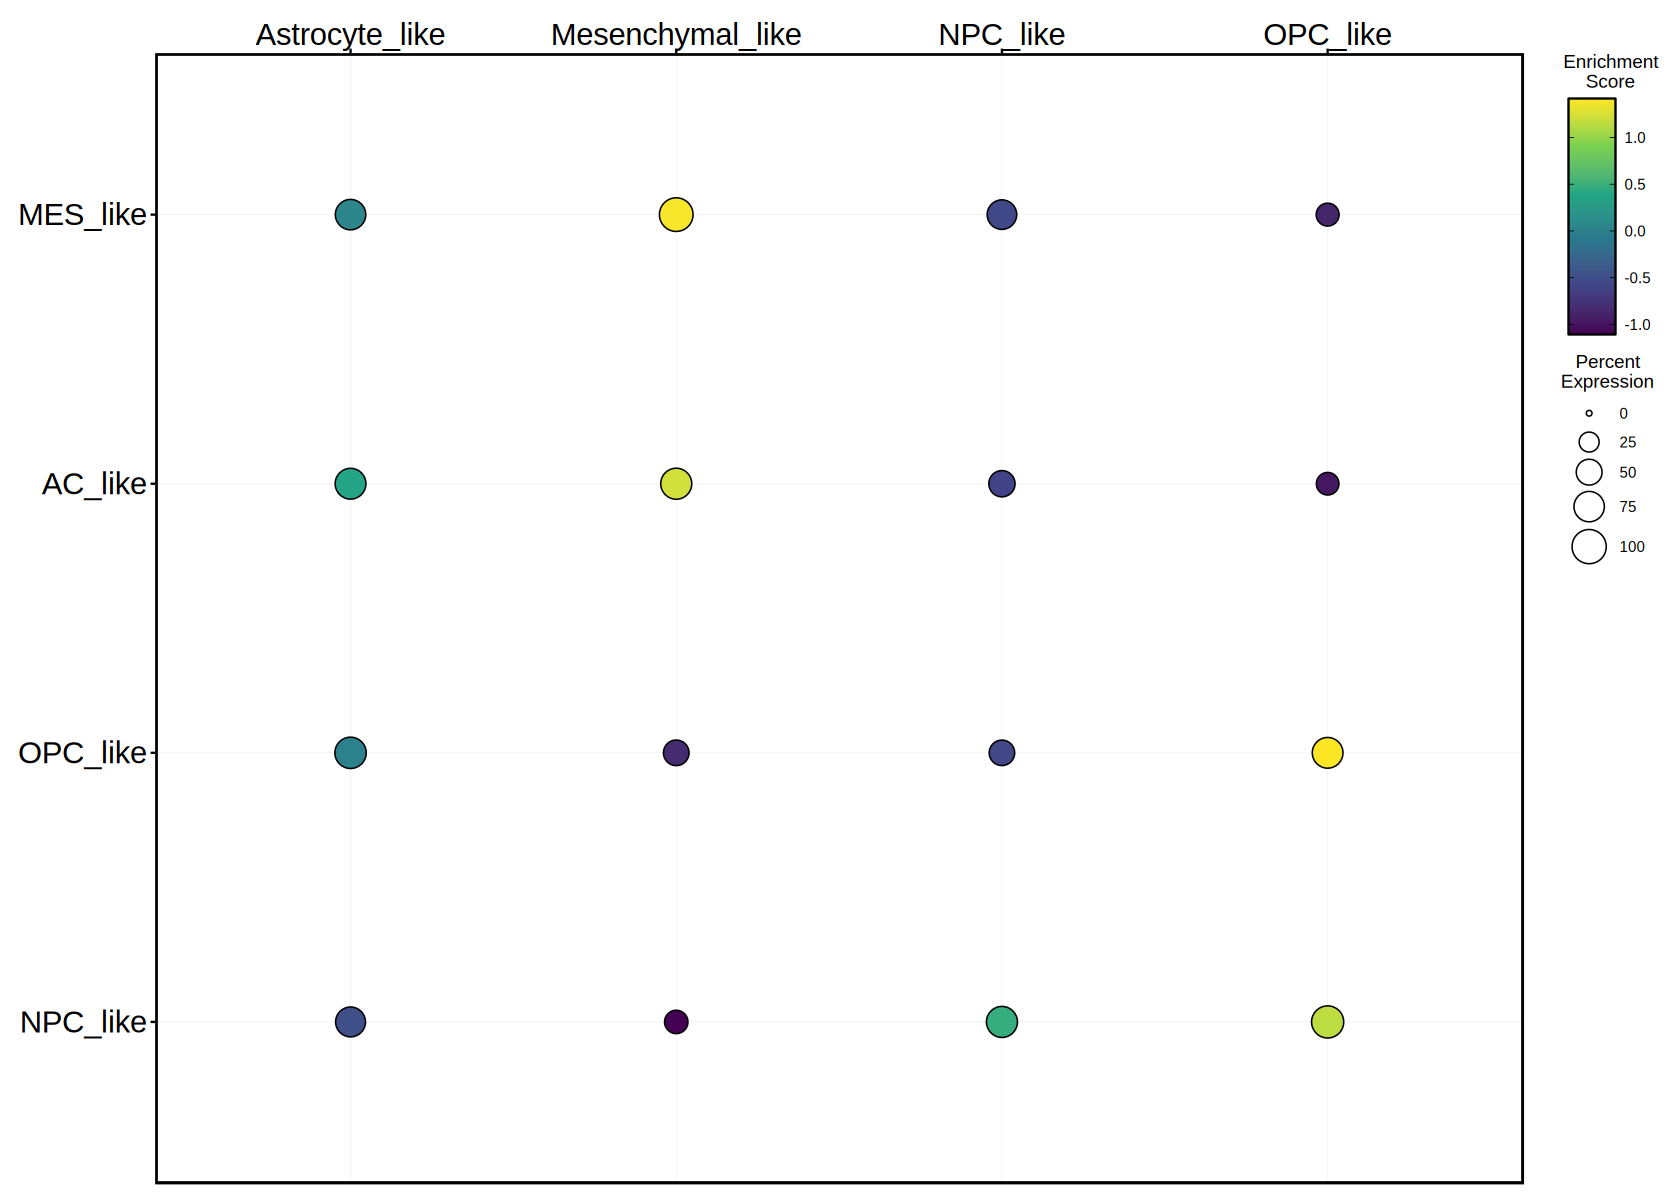

In [33]:
message("Generating plot...")

final_dotplot <- create_publication_dotplot(
  seu_obj = obj_tumor,
  features = new_names,        # Your vector of metadata column names
  group_by = "general_cell_type",
  scale_data = TRUE,           # Scale Z-scores for better relative comparison
  dot_range = c(1, 9)          # Slight tweak to range for visibility
)
final_dotplot